# AutoRAG 벤치마크 결과 분석

## 개요

`embedding_combinations_lab.ipynb`에서 설계한 6가지 임베딩 조합 RAG 파이프라인을  
**AutoRAG** 프레임워크로 정량적으로 평가한 결과를 분석합니다.

### RAG 파이프라인이란?

**RAG (Retrieval-Augmented Generation)**은 LLM이 답변을 생성하기 전에, 관련 문서를 먼저 검색하여 컨텍스트로 제공하는 방식입니다.

```
질문 → [검색(Retrieval)] → 관련 문서 추출 → [생성(Generation)] → 답변
```

AutoRAG는 이 파이프라인의 **각 단계에서 어떤 모듈 조합이 최적인지**를 자동으로 실험하고 비교해주는 프레임워크입니다.

### 벤치마크 구성

| Trial | Config | 설명 |
|-------|--------|------|
| **Trial 0** | `benchmark_config.yaml` | Dense Retrieval only — 5개 임베딩 모델의 순수 벡터 검색 성능 비교 |
| **Trial 1** | `hybrid_benchmark_config.yaml` | Dense + Sparse(BM25) + Hybrid Fusion + Reranker — 전체 파이프라인 최적화 |

### 평가 메트릭 해설

#### Retrieval (검색) 메트릭
| 메트릭 | 의미 | 직관적 설명 |
|--------|------|------------|
| **Recall** | 정답 문서 중 실제로 검색된 비율 | "찾아야 할 문서를 얼마나 놓치지 않았는가" |
| **Precision** | 검색된 문서 중 정답 문서의 비율 | "검색된 문서 중 쓸모있는 것의 비율" |
| **F1** | Recall과 Precision의 조화 평균 | "검색의 전반적 균형 점수" |

> **참고**: top_k=10으로 10개 문서를 가져오면 Precision은 자연스럽게 낮아집니다 (정답이 1~2개인 경우 최대 0.1~0.2).  
> 따라서 이 벤치마크에서는 **Recall이 가장 중요한 지표**입니다.

#### Generation (생성) 메트릭
| 메트릭 | 의미 | 직관적 설명 |
|--------|------|------------|
| **BLEU** | 생성 답변과 정답의 n-gram 일치도 (0~100) | "단어 단위로 정답과 얼마나 겹치는가" |
| **METEOR** | 동의어/어근까지 고려한 일치도 (0~1) | "의미적으로 비슷한 표현도 인정하는 BLEU" |
| **ROUGE** | 정답 대비 생성 텍스트의 겹침 비율 (0~1) | "정답의 핵심 내용을 얼마나 포함하는가" |
| **Sem Score** | 임베딩 기반 의미적 유사도 (0~1) | "문장 전체의 의미가 정답과 얼마나 가까운가" |

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path('autorag_benchmark/results')
print(f'결과 디렉토리: {RESULTS_DIR}')
print(f'Trial 목록: {sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.isdigit()])}')

결과 디렉토리: autorag_benchmark/results
Trial 목록: ['0', '1']


---
## 0단계: 벤치마크 데이터셋

벤치마크를 이해하려면 먼저 **어떤 데이터로 평가하는지** 알아야 합니다.  
AutoRAG는 두 가지 데이터셋을 사용합니다:

1. **Corpus (문서 청크)**: 검색 대상이 되는 문서 조각들. PDF를 파싱하고 청킹하여 생성
2. **QA (질문-답변 쌍)**: 벤치마크 평가 기준. GPT-4o-mini가 Corpus를 읽고 자동 생성한 질문과 정답

```
원본 PDF → [파싱+청킹] → Corpus (299개 청크) → [GPT-4o-mini QA 생성] → QA 데이터셋 (100개 질문)
```

> **평가 원리**: 검색 시스템이 각 질문에 대해 `retrieval_gt`에 지정된 정답 문서를 찾으면 Recall +1,  
> 생성 시스템의 답변이 `generation_gt`와 유사하면 BLEU/ROUGE 점수 상승

In [33]:
# 데이터셋 통계
qa = pd.read_parquet('autorag_benchmark/data/qa.parquet')
corpus = pd.read_parquet('autorag_benchmark/data/corpus.parquet')

print(f'QA 데이터셋: {len(qa)}개 질문')
print(f'Corpus 데이터셋: {len(corpus)}개 문서 청크')
print(f'\n문서 소스:')
for path in corpus['path'].unique():
    count = len(corpus[corpus['path'] == path])
    print(f'  - {Path(path).name}: {count}개 청크')

QA 데이터셋: 100개 질문
Corpus 데이터셋: 299개 문서 청크

문서 소스:
  - 20250910_AI 현황 보고서.pdf: 255개 청크
  - SPRi AI Brief_1월호_산업동향_0102_F.pdf: 44개 청크


### QA 데이터셋 구조

벤치마크의 **평가 기준**이 되는 QA 데이터셋입니다.  
GPT-4o-mini가 Corpus 문서를 읽고 자동 생성한 질문-답변 쌍으로 구성됩니다.

| 컬럼 | 타입 | 설명 |
|------|------|------|
| `qid` | string | 질문 고유 ID (UUID) |
| `query` | string | 질문 텍스트 |
| `retrieval_gt` | list[list[str]] | **정답 문서 ID** — 이 질문에 대해 검색되어야 하는 Corpus 문서의 doc_id |
| `generation_gt` | list[str] | **정답 답변** — 이 질문에 대한 모범 답변 텍스트 |

> `retrieval_gt`는 검색 메트릭(Recall, F1) 계산에, `generation_gt`는 생성 메트릭(BLEU, ROUGE) 계산에 사용됩니다.

In [34]:
# QA 데이터셋 미리보기 (질문 + 정답 답변)
print('=== QA 데이터셋 미리보기 (처음 10개) ===\n')

qa_display = qa.copy()
qa_display['generation_gt_text'] = qa_display['generation_gt'].apply(lambda x: x[0] if len(x) > 0 else '')
qa_display['retrieval_gt_count'] = qa_display['retrieval_gt'].apply(lambda x: len(x[0]) if len(x) > 0 else 0)

qa_preview = (qa_display[['query', 'generation_gt_text', 'retrieval_gt_count']]
    .head(10)
    .rename(columns={
        'query': '질문 (query)',
        'generation_gt_text': '정답 답변 (generation_gt)',
        'retrieval_gt_count': '정답 문서 수'
    })
)

display(qa_preview.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '400px'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    ])
)

=== QA 데이터셋 미리보기 (처음 10개) ===



,질문 (query),정답 답변 (generation_gt),정답 문서 수
0,What is the name of the open-source AI agent framework that was transferred to the AAIF for operation in January 2025?,The name of the open-source AI agent framework that was transferred to the AAIF for operation in January 2025 is '구스' (Goose).,1
1,When is the new generative AI platform 'GenAI.mil' set to be launched by the U.S. Department of War?,"The new generative AI platform 'GenAI.mil' is set to be launched by the U.S. Department of War on December 9, 2025.",1
2,What is the ultimate goal of Kimi K2 beyond chatbot capabilities?,"The ultimate goal of Kimi K2, beyond chatbot capabilities, is to provide an experience that can instantly create frontend applications such as PowerPoint presentations and mini-games. This reflects a vision of expanding the functionality of AI beyond simple conversational tasks to more complex and interactive applications.",1
3,What trend has been observed in the hiring of new employees compared to experienced employees since mid-2022?,"Since mid-2022, a clear trend has been observed where the hiring of new employees has stopped growing and has even turned to a decline, while the hiring of experienced employees has continued to increase. This phenomenon is described as a decoupling effect, indicating that the employment landscape is shifting in favor of experienced workers at the expense of new hires.",1
4,"What is the estimated AI investment scale by major tech companies for the second quarter, and how does it compare to the previous forecast?","The estimated AI investment scale by major tech companies for the second quarter is $364 billion, which represents a 12% increase compared to the previous forecast of $325 billion made in February.",1
5,What is the release date of the GPT-5.2 AI model?,"The release date of the GPT-5.2 AI model is December 11, 2025.",1
6,What is the expected power demand for U.S. data centers by 2028 according to S&P Global?,"According to S&P Global, the expected power demand for U.S. data centers is projected to double by 2028, reaching 95GW.",1
7,What is the significance of 'Sovereign AI' in the context of national security and the US-China power competition?,"'Sovereign AI' is significant in the context of national security and the US-China power competition as it represents a strategic asset that directly impacts a nation's security. Countries are prioritizing the development of 'Sovereign AI' based on their own data and cultural contexts, which has become a new front in the power struggle between the US and China. OpenAI emphasizes the necessity for the US to win the superintelligence competition against China, highlighting the geopolitical stakes involved. The intertwining of AI with defense strategies is evident, as seen in OpenAI's contract with the Pentagon for military AI development and NVIDIA's decision to host AI events in Washington, DC. This indicates that AI is not just a technological advancement but a critical component of national defense and international relations, with the US pushing its allies to choose between American or Chinese AI technologies.",1
8,What is the goal of Isomorphic Labs in relation to AI drug development?,"The goal of Isomorphic Labs in relation to AI drug development is to utilize artificial intelligence to design new drugs that can effectively treat diseases and extend healthy lifespans. They aim to significantly shorten the drug development timeline from the traditional 5-10 years to just 1-2 years by leveraging advanced technologies like Google DeepMind's AlphaFold 3, which predicts molecular interactions. Ultimately, Isomorphic Labs seeks to simulate the functioning of entire cells to predict outcomes when drugs are administered, thereby enhancing the efficacy of treatments for major diseases such as cancer and immune-related conditions.",1
9,What significant decision did Apple make regarding the development of MLX to support NVIDIA's CUDA?,"Apple made a significant decision to direct

In [35]:
# QA 샘플 상세 보기: 질문 → 정답 문서 → 정답 답변 연결
print('=== QA 샘플 상세 보기 (3건) ===')
print('질문이 어떤 Corpus 문서에서 나왔고, 어떤 답변이 기대되는지 확인합니다.\n')

for i in range(3):
    row = qa.iloc[i]
    gt_doc_ids = row['retrieval_gt'][0] if len(row['retrieval_gt']) > 0 else []
    gt_answer = row['generation_gt'][0] if len(row['generation_gt']) > 0 else ''

    print(f'{"─" * 80}')
    print(f'  #{i+1} 질문: {row["query"]}')
    print(f'{"─" * 80}')

    # 정답 문서 내용 표시
    for doc_id in gt_doc_ids:
        doc_row = corpus[corpus['doc_id'] == doc_id]
        if not doc_row.empty:
            doc = doc_row.iloc[0]
            source = Path(doc['path']).name if 'path' in doc else 'N/A'
            content_preview = doc['contents'][:300].replace('\n', ' ')
            print(f'  [정답 문서] ID: {doc_id[:12]}... | 출처: {source}')
            print(f'  [문서 내용] {content_preview}...')

    print(f'  [정답 답변] {gt_answer[:200]}')
    if len(row['generation_gt']) > 1:
        print(f'  [추가 답변] {row["generation_gt"][1][:100]}')
    print()

=== QA 샘플 상세 보기 (3건) ===
질문이 어떤 Corpus 문서에서 나왔고, 어떤 답변이 기대되는지 확인합니다.

────────────────────────────────────────────────────────────────────────────────
  #1 질문: What is the name of the open-source AI agent framework that was transferred to the AAIF for operation in January 2025?
────────────────────────────────────────────────────────────────────────────────
  [정답 문서] ID: 49010f3a-d1e... | 출처: SPRi AI Brief_1월호_산업동향_0102_F.pdf
  [문서 내용] 파일 제목: SPRi AI Brief_1월호_산업동향_0102_F.pdf  내용: 주도 중심의 MCP 생태계를 유지하겠다는 취지를 강조  n 블록은 로컬에서 실행되는 오픈소스 AI 에이전트 프레임워크 ‘구스(Goose)’의 운영을 AAIF에 이관   ∙ 2025년 1월 공개된 구스는 AI 모델과 확장형 도구, MCP 기반 표준 통합을 바탕으로 각 조직이 필요에   맞는 AI 에이전트를 직접 구축하고 운영하기 위한 체계적이고 신뢰할 수 있는 환경을 제공   ∙ 블록은 에이전틱 AI의 안전하고 일관성 있는 발전에 필...
  [정답 답변] The name of the open-source AI agent framework that was transferred to the AAIF for operation in January 2025 is '구스' (Goose).
  [추가 답변] 구스(Goose)

────────────────────────────────────────────────────────────────────────────────
  #2 질

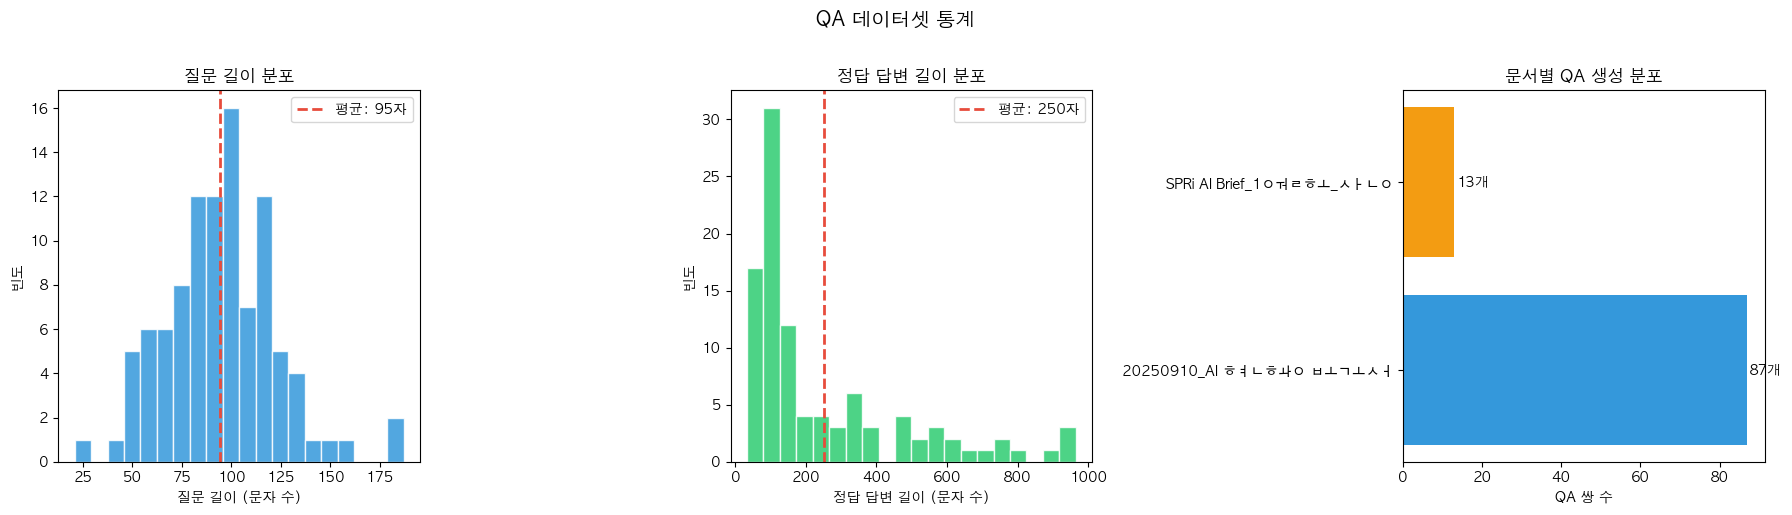


요약: 질문 평균 95자, 답변 평균 250자, 질문당 정답 문서 1개


In [36]:
# QA 데이터셋 통계 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 질문 길이 분포
query_lens = qa['query'].str.len()
axes[0].hist(query_lens, bins=20, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(query_lens.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'평균: {query_lens.mean():.0f}자')
axes[0].set_xlabel('질문 길이 (문자 수)')
axes[0].set_ylabel('빈도')
axes[0].set_title('질문 길이 분포')
axes[0].legend()

# 2) 정답 답변 길이 분포
answer_lens = qa['generation_gt'].apply(lambda x: len(x[0]) if len(x) > 0 else 0)
axes[1].hist(answer_lens, bins=20, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axvline(answer_lens.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'평균: {answer_lens.mean():.0f}자')
axes[1].set_xlabel('정답 답변 길이 (문자 수)')
axes[1].set_ylabel('빈도')
axes[1].set_title('정답 답변 길이 분포')
axes[1].legend()

# 3) Corpus 문서별 QA 생성 수 (어느 문서에서 질문이 많이 나왔는가)
qa_doc_sources = []
for _, row in qa.iterrows():
    gt_doc_ids = row['retrieval_gt'][0] if len(row['retrieval_gt']) > 0 else []
    for doc_id in gt_doc_ids:
        doc_row = corpus[corpus['doc_id'] == doc_id]
        if not doc_row.empty:
            qa_doc_sources.append(Path(doc_row.iloc[0]['path']).stem[:25])

source_counts = pd.Series(qa_doc_sources).value_counts()
bars = axes[2].barh(source_counts.index, source_counts.values, color=['#3498db', '#f39c12'])
axes[2].set_xlabel('QA 쌍 수')
axes[2].set_title('문서별 QA 생성 분포')
for bar, v in zip(bars, source_counts.values):
    axes[2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2., f'{v}개', va='center', fontweight='bold')

plt.suptitle('QA 데이터셋 통계', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n요약: 질문 평균 {query_lens.mean():.0f}자, 답변 평균 {answer_lens.mean():.0f}자, 질문당 정답 문서 1개')

### Corpus 데이터셋 구조

검색 대상이 되는 **문서 청크(chunk)** 모음입니다. 원본 PDF를 파싱하고 청킹하여 생성되었습니다.

| 컬럼 | 타입 | 설명 |
|------|------|------|
| `doc_id` | string | 문서 청크 고유 ID (UUID) |
| `contents` | string | 청크 텍스트 내용 |
| `path` | string | 원본 PDF 파일 경로 |
| `start_end_idx` | string | 원본 문서에서의 시작-끝 문자 위치 |
| `metadata` | dict | 추가 메타데이터 (파일명 등) |

In [37]:
# Corpus 데이터셋 미리보기
print('=== Corpus 데이터셋 미리보기 (처음 5개 청크) ===\n')

corpus_display = corpus.copy()
corpus_display['source'] = corpus_display['path'].apply(lambda x: Path(x).name)
corpus_display['content_preview'] = corpus_display['contents'].str[:150] + '...'
corpus_display['content_length'] = corpus_display['contents'].str.len()

corpus_preview = (corpus_display[['doc_id', 'source', 'content_preview', 'content_length']]
    .head(5)
    .rename(columns={
        'doc_id': '문서 ID',
        'source': '출처 파일',
        'content_preview': '내용 미리보기',
        'content_length': '청크 길이(자)'
    })
)

display(corpus_preview.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '500px'})
)

# Corpus 통계
print(f'\n--- Corpus 통계 ---')
print(f'총 청크 수: {len(corpus)}개')
print(f'청크 평균 길이: {corpus_display["content_length"].mean():.0f}자')
print(f'청크 최소/최대 길이: {corpus_display["content_length"].min()}자 / {corpus_display["content_length"].max()}자')

=== Corpus 데이터셋 미리보기 (처음 5개 청크) ===



,문서 ID,출처 파일,내용 미리보기,청크 길이(자)
0,d1c7d2ea-d546-4279-9bdd-e7c7edf03d9e,20250910_AI 현황 보고서.pdf,파일 제목: 20250910_AI 현황 보고서.pdf 내용: Knowledge Cutoff | 2025. 9. 10 AI 현황 보고서 풀스택 헤게모니에 관하여 한종목 chongmok.han@miraeasset.com 1 | AI 현황 보고서 Mir...,1160
1,9b35343c-2a88-4f80-b8ce-04342c820cc4,20250910_AI 현황 보고서.pdf,파일 제목: 20250910_AI 현황 보고서.pdf 내용: 시대의 종말’과 ‘추론 (Inference) 및 강화학습(RL) 스케일링’이라는 새로운 패러다임의 등장을 심층 분석합니다. 이 두 장을 통해 독자께서는 AI 혁명이 왜 과거와 근본적으로 다른지에...,1039
2,ae01e393-38c7-41bc-85bf-c78e30dd6fe5,20250910_AI 현황 보고서.pdf,"파일 제목: 20250910_AI 현황 보고서.pdf 내용: 역설합니다. AI는 더 이상 소프트웨어나 알고리즘만의 영역이 아니며, 에너지, 반도체, 데이터, 지정학, 그리고 물리적 구현에 이르는 ‘풀 스택(Full-stack)’을 장악하는 자가 미래의 부...",1113
3,37b1a346-468e-429a-806c-2569d89527e8,20250910_AI 현황 보고서.pdf,파일 제목: 20250910_AI 현황 보고서.pdf 내용: 샘 알트만과 일론 머스크는 2025년 말을 AGI 등장 시점으로 예측.AI 선도 기업들은 대중에 공개된 모델보다 3~9개월 앞선 내부 모델을 보유. 현재 우리가 경험하는 AI는 이미 과거 버전...,1201
4,41f8c7d8-85c6-41c8-906e-5de100c80472,20250910_AI 현황 보고서.pdf,"파일 제목: 20250910_AI 현황 보고서.pdf 내용: 데이터 분석 보조 도구를 넘어, 인간이 상상하지 못한 실험을 설계하는 과학적 '파트너'로 격상. • LIGO(중력파 검출기) 사례가 대표적. 인간 과학자들은 AI가 제안한 “이상하고 비대칭적이...",1132



--- Corpus 통계 ---
총 청크 수: 299개
청크 평균 길이: 1139자
청크 최소/최대 길이: 499자 / 1701자


---
## 1단계: Dense Retrieval 결과 (Trial 0)

### Dense Retrieval이란?
문서와 질문을 각각 **임베딩 벡터**(고차원 숫자 배열)로 변환한 뒤,  
벡터 간 **코사인 유사도**로 의미적으로 가장 가까운 문서를 찾는 방식입니다.

```
질문 "AI 윤리 이슈는?" → 임베딩 [0.12, -0.34, ...] → Qdrant VectorDB에서 유사 벡터 검색 → top_k=10개 문서 반환
```

### 비교 대상: 5개 임베딩 모델

| 모델 | 차원 | 특징 |
|------|------|------|
| **E5 multilingual** | 1024 | 다국어 범용, 한국어 포함 100+ 언어 지원 |
| **BGE-M3** | 1024 | Dense+Sparse+ColBERT 올인원 모델 |
| **OpenAI embed-3-large** | 3072 | 최고 차원, API 기반 유료 모델 |
| **KoSimCSE** | 768 | 한국어 전용 문장 유사도 모델 |
| **MiniLM L6-v2** | 384 | 경량/고속, 영어 중심 |

> **핵심 질문**: 한국어 AI 보고서 검색에 어떤 임베딩 모델이 가장 효과적인가?

In [38]:
# Trial 0: Dense-only 결과 로드
trial0_dir = RESULTS_DIR / '0'

# 전체 요약
summary_0 = pd.read_csv(trial0_dir / 'summary.csv')
print('=== Trial 0: Dense-only 최적 파이프라인 ===')
display(summary_0)

=== Trial 0: Dense-only 최적 파이프라인 ===


,node_line_name,node_type,best_module_filename,best_module_name,best_module_params,best_execution_time
0,retrieve_and_generate,semantic_retrieval,2.parquet,VectorDB,"{'top_k': 10, 'vectordb': 'e5_qdrant'}",3.971573
1,retrieve_and_generate,prompt_maker,0.parquet,Fstring,"{'prompt': 'Based on the following context, an...",0.000066
2,retrieve_and_generate,generator,0.parquet,LlamaIndexLLM,"{'llm': 'openai', 'model': 'gpt-4o-mini', 'tem...",0.210330


In [39]:
# Semantic Retrieval 상세 결과
retrieval_0 = pd.read_csv(trial0_dir / 'retrieve_and_generate' / 'semantic_retrieval' / 'summary.csv')

# 모델 이름 추출
retrieval_0['model'] = retrieval_0['module_params'].apply(
    lambda x: eval(x).get('vectordb', 'unknown').replace('_qdrant', '')
)

model_display = {
    'openai': 'OpenAI\nembed-3-large',
    'minilm': 'MiniLM\nL6-v2',
    'e5': 'E5\nmultilingual',
    'bge_m3': 'BGE-M3',
    'kosimcse': 'KoSimCSE\nroberta',
}
retrieval_0['model_display'] = retrieval_0['model'].map(model_display)

print('=== 임베딩 모델별 Retrieval 성능 ===')
display(retrieval_0[['model', 'retrieval_recall', 'retrieval_f1', 'retrieval_precision', 'execution_time', 'is_best']]
        .sort_values('retrieval_recall', ascending=False)
        .reset_index(drop=True))

=== 임베딩 모델별 Retrieval 성능 ===


,model,retrieval_recall,retrieval_f1,retrieval_precision,execution_time,is_best
0,e5,0.95,0.172727,0.095,3.971573,True
1,bge_m3,0.95,0.172727,0.095,3.275472,False
2,openai,0.92,0.167273,0.092,0.612646,False
3,kosimcse,0.58,0.105455,0.058,0.181333,False
4,minilm,0.29,0.052727,0.029,0.077451,False


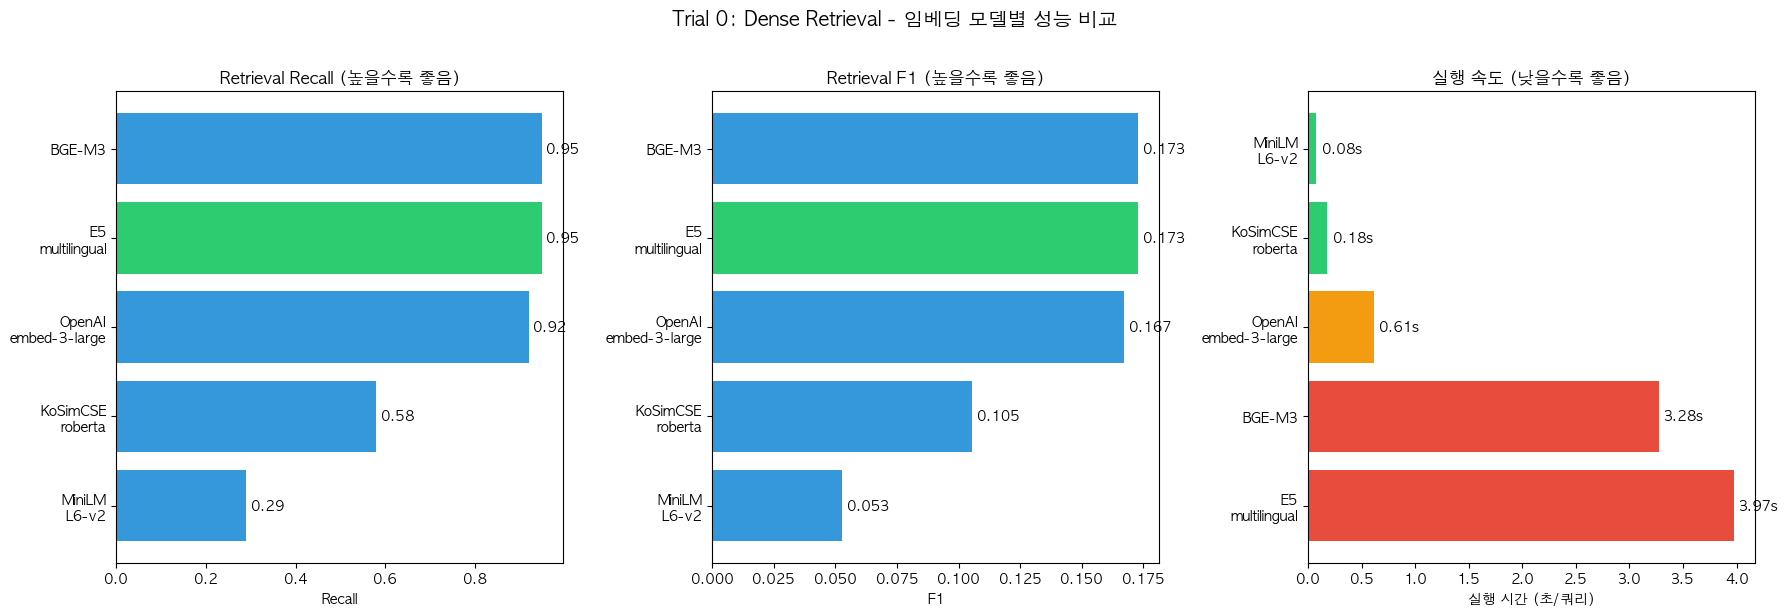

In [40]:
# 시각화: Retrieval Recall 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 색상 설정
colors = ['#2ecc71' if b else '#3498db' for b in retrieval_0.sort_values('retrieval_recall', ascending=True)['is_best']]
sorted_df = retrieval_0.sort_values('retrieval_recall', ascending=True)

# Recall
axes[0].barh(sorted_df['model_display'], sorted_df['retrieval_recall'], color=colors)
axes[0].set_xlabel('Recall')
axes[0].set_title('Retrieval Recall (높을수록 좋음)')
for i, v in enumerate(sorted_df['retrieval_recall']):
    axes[0].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

# F1
sorted_df_f1 = retrieval_0.sort_values('retrieval_f1', ascending=True)
colors_f1 = ['#2ecc71' if b else '#3498db' for b in sorted_df_f1['is_best']]
axes[1].barh(sorted_df_f1['model_display'], sorted_df_f1['retrieval_f1'], color=colors_f1)
axes[1].set_xlabel('F1')
axes[1].set_title('Retrieval F1 (높을수록 좋음)')
for i, v in enumerate(sorted_df_f1['retrieval_f1']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

# 실행 속도
sorted_df_time = retrieval_0.sort_values('execution_time', ascending=False)
colors_time = ['#e74c3c' if t > 2 else '#f39c12' if t > 0.5 else '#2ecc71' for t in sorted_df_time['execution_time']]
axes[2].barh(sorted_df_time['model_display'], sorted_df_time['execution_time'], color=colors_time)
axes[2].set_xlabel('실행 시간 (초/쿼리)')
axes[2].set_title('실행 속도 (낮을수록 좋음)')
for i, v in enumerate(sorted_df_time['execution_time']):
    axes[2].text(v + 0.05, i, f'{v:.2f}s', va='center', fontweight='bold')

plt.suptitle('Trial 0: Dense Retrieval - 임베딩 모델별 성능 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 결과 해석: Dense Retrieval 성능

**3개 그룹으로 뚜렷하게 나뉨:**

| 그룹 | 모델 | Recall | 해석 |
|------|------|--------|------|
| **1군 (우수)** | E5, BGE-M3 | 0.95 | 100개 질문 중 95개에서 정답 문서를 찾음 |
| **2군 (양호)** | OpenAI | 0.92 | 근소한 차이로 1군에 근접 |
| **3군 (부족)** | KoSimCSE, MiniLM | 0.29~0.58 | 절반 이상의 질문에서 정답 문서를 못 찾음 |

**왜 이런 차이가 날까?**
- **E5/BGE-M3**: 대규모 다국어 학습 데이터로 한국어 의미 이해 능력이 뛰어남
- **OpenAI**: 고차원(3072)이지만 API 기반이라 한국어 특화도에서 약간 뒤처짐
- **KoSimCSE**: 한국어 '전용'이지만 문장 유사도 태스크에 최적화되어 문서 검색과는 다소 괴리
- **MiniLM**: 영어 중심 모델로 한국어 문서에서는 성능이 크게 떨어짐

**is_best 컬럼**: AutoRAG가 F1 기준으로 자동 선택한 최적 모듈. E5와 BGE-M3가 동일 성능이지만 E5가 먼저 평가되어 Best로 선택됨

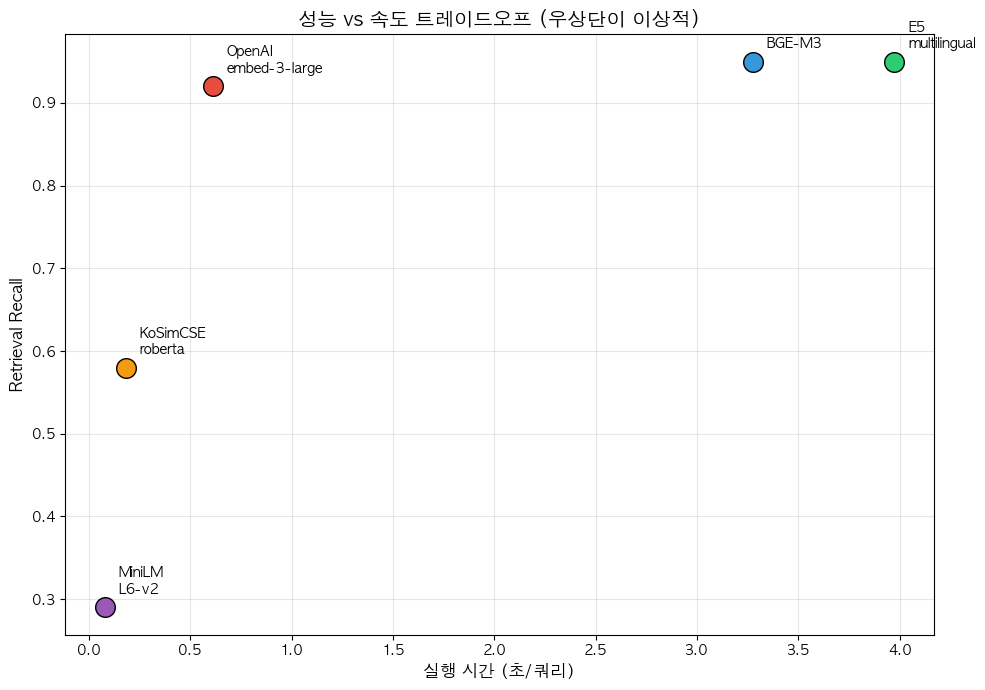

In [41]:
# 시각화: 성능 vs 속도 트레이드오프
fig, ax = plt.subplots(figsize=(10, 7))

scatter_colors = {'openai': '#e74c3c', 'minilm': '#9b59b6', 'e5': '#2ecc71', 'bge_m3': '#3498db', 'kosimcse': '#f39c12'}
for _, row in retrieval_0.iterrows():
    ax.scatter(row['execution_time'], row['retrieval_recall'],
              s=200, c=scatter_colors[row['model']], edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(row['model_display'], (row['execution_time'], row['retrieval_recall']),
               textcoords='offset points', xytext=(10, 10), fontsize=10)

ax.set_xlabel('실행 시간 (초/쿼리)', fontsize=12)
ax.set_ylabel('Retrieval Recall', fontsize=12)
ax.set_title('성능 vs 속도 트레이드오프 (우상단이 이상적)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 결과 해석: 성능 vs 속도 트레이드오프

위 산점도에서 **우상단(높은 Recall + 짧은 시간)**이 이상적입니다.

| 모델 | 판단 |
|------|------|
| **OpenAI** | 가장 균형 잡힌 선택 — Recall 0.92 + 0.61초. API 호출이므로 로컬 GPU 불필요 |
| **BGE-M3** | Recall 최고(0.95)이지만 3.3초로 느림. 로컬 HuggingFace 모델이라 GPU 가속 시 개선 가능 |
| **E5** | BGE-M3와 동일 성능이지만 약간 더 느림(3.97초). 실운영 시 BGE-M3가 더 효율적 |
| **KoSimCSE / MiniLM** | 빠르지만 Recall이 너무 낮아 실용성 부족 |

> **실운영 권장**: 비용 고려 시 **BGE-M3** (무료 로컬), 편의성 고려 시 **OpenAI** (API)

---
## 2단계: Generator 결과 (Trial 0)

### Generator란?
검색된 문서를 컨텍스트로 받아 **최종 답변을 생성**하는 LLM 단계입니다.

```
[검색된 문서 10개] + [질문] → GPT-4o-mini → "답변 텍스트"
```

### 비교 대상: temperature 파라미터
- **temperature = 0**: 항상 가장 확률 높은 토큰을 선택 (결정적, 일관된 답변)
- **temperature = 0.3**: 약간의 무작위성 추가 (다양하지만 약간 불안정)

> **핵심 질문**: RAG에서 생성 답변은 얼마나 정확하며, temperature가 품질에 영향을 미치는가?

=== Generator 성능 (GPT-4o-mini) ===


,temperature,bleu,meteor,rouge,average_output_token,is_best
0,0.0,66.957866,0.801134,0.769744,62.25,True
1,0.3,65.961166,0.797415,0.766226,61.52,False


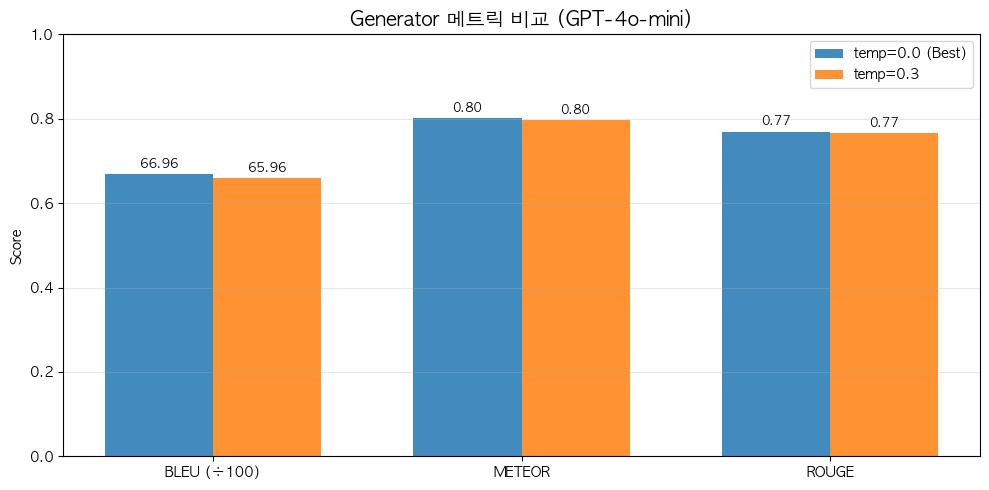

In [42]:
# Generator 결과
generator_0 = pd.read_csv(trial0_dir / 'retrieve_and_generate' / 'generator' / 'summary.csv')
generator_0['temperature'] = generator_0['module_params'].apply(lambda x: eval(x).get('temperature', 'N/A'))

print('=== Generator 성능 (GPT-4o-mini) ===')
display(generator_0[['temperature', 'bleu', 'meteor', 'rouge', 'average_output_token', 'is_best']])

# 시각화
metrics = ['bleu', 'meteor', 'rouge']
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(metrics))
width = 0.35

for i, (_, row) in enumerate(generator_0.iterrows()):
    values = [row['bleu'] / 100, row['meteor'], row['rouge']]  # normalize bleu to 0-1
    label = f"temp={row['temperature']}" + (' (Best)' if row['is_best'] else '')
    bars = ax.bar(x + i * width, values, width, label=label, alpha=0.85)
    for bar, val in zip(bars, [row['bleu'], row['meteor'], row['rouge']]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
               f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Generator 메트릭 비교 (GPT-4o-mini)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(['BLEU (÷100)', 'METEOR', 'ROUGE'])
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 결과 해석: Generator 성능

| 항목 | temp=0 | temp=0.3 | 차이 |
|------|--------|----------|------|
| BLEU | **66.96** | 65.96 | -1.5% |
| METEOR | **0.801** | 0.797 | -0.5% |
| ROUGE | **0.770** | 0.766 | -0.5% |
| 평균 출력 토큰 | 62.25 | 61.52 | 거의 동일 |

**해석:**
- **temperature=0이 모든 메트릭에서 우수** → RAG에서는 창의성보다 정확성이 중요하므로 당연한 결과
- **BLEU 66.96은 매우 높은 수치** → 생성 답변이 정답과 단어 수준에서 크게 겹침. QA 데이터셋 자체가 GPT-4o-mini로 생성되었기 때문에 같은 모델이 유리한 측면도 있음
- **METEOR 0.80** → 동의어/어형 변화까지 고려해도 80% 수준의 일치도
- **차이가 미미함 (1% 내외)** → 이 태스크에서 temperature 변화의 영향은 작음

> **결론**: RAG 생성에서는 **temperature=0** (결정적 생성)이 안정적이며 최적

---
## 3단계: Hybrid Retrieval 결과 (Trial 1)

Trial 1은 Dense 검색 단독이 아닌, **4단계 검색 파이프라인**을 평가합니다.

### 파이프라인 구조

```
질문 ─┬─ [Dense 검색] ─── E5 임베딩 → Qdrant 벡터 유사도 ──┐
      │                                                      ├─ [Hybrid 융합] ─── 두 결과를 합쳐 최적 순위 생성 ─── [Reranker] ─── 최종 top_k개 선별
      └─ [Sparse 검색] ── BM25 키워드 매칭 ─────────────────┘
```

### 각 단계의 역할

| 단계 | 모듈 | 하는 일 |
|------|------|---------|
| **Dense (의미 검색)** | VectorDB | "AI 윤리"라는 질문의 의미를 이해하여 관련 문서 검색 |
| **Sparse (키워드 검색)** | BM25 | "AI", "윤리" 단어가 직접 포함된 문서 검색 |
| **Hybrid 융합** | HybridCC / HybridRRF | Dense와 Sparse 결과를 가중 결합하여 상호 보완 |
| **Reranker** | KoReranker | 융합 결과를 Cross-encoder로 재순위화하여 정밀도 향상 |

### Hybrid 융합 방식 비교
- **HybridRRF**: Reciprocal Rank Fusion — 순위 기반 결합 (파라미터 1개: weight)
- **HybridCC**: Convex Combination — 점수 정규화 후 가중 평균 (파라미터: normalize_method + weight)
  - `tmm`: 잘림 최소-최대 정규화
  - `mm`: 일반 최소-최대 정규화

In [43]:
trial1_dir = RESULTS_DIR / '1'

if trial1_dir.exists() and (trial1_dir / 'summary.csv').exists():
    summary_1 = pd.read_csv(trial1_dir / 'summary.csv')
    print('=== Trial 1: Hybrid 최적 파이프라인 ===')
    display(summary_1)
else:
    print('Trial 1 결과가 아직 없습니다. Hybrid 벤치마크 완료 후 다시 실행하세요.')

=== Trial 1: Hybrid 최적 파이프라인 ===


,node_line_name,node_type,best_module_filename,best_module_name,best_module_params,best_execution_time
0,retrieve_node_line,semantic_retrieval,0.parquet,VectorDB,"{'top_k': 10, 'vectordb': 'e5_qdrant'}",0.902891
1,retrieve_node_line,lexical_retrieval,1.parquet,BM25,"{'top_k': 10, 'bm25_tokenizer': 'ko_kiwi'}",1.496899
2,retrieve_node_line,hybrid_retrieval,1.parquet,HybridCC,"{'top_k': 10, 'normalize_method': 'tmm', 'weig...",0.084135
3,retrieve_node_line,passage_reranker,1.parquet,KoReranker,{'top_k': 5},8.867755
4,post_retrieve_node_line,prompt_maker,0.parquet,Fstring,{'prompt': '다음 참고 자료를 활용하여 질문에 정확하게 답하세요.\n\n참...,0.000041
5,post_retrieve_node_line,generator,0.parquet,LlamaIndexLLM,"{'llm': 'openai', 'model': 'gpt-4o-mini', 'tem...",0.227707


In [44]:
# Hybrid Retrieval 노드별 상세 결과
if trial1_dir.exists():
    node_line_dir = trial1_dir / 'retrieve_node_line'

    # Semantic Retrieval
    semantic_csv = node_line_dir / 'semantic_retrieval' / 'summary.csv'
    if semantic_csv.exists():
        semantic_1 = pd.read_csv(semantic_csv)
        print('=== Dense Retrieval (Trial 1) ===')
        display(semantic_1[['module_name', 'module_params', 'retrieval_recall', 'retrieval_f1', 'is_best']])

    # Lexical Retrieval (BM25)
    lexical_csv = node_line_dir / 'lexical_retrieval' / 'summary.csv'
    if lexical_csv.exists():
        lexical_1 = pd.read_csv(lexical_csv)
        print('\n=== Sparse Retrieval - BM25 (Trial 1) ===')
        display(lexical_1[['module_name', 'module_params', 'retrieval_recall', 'retrieval_f1', 'is_best']])

    # Hybrid Retrieval
    hybrid_csv = node_line_dir / 'hybrid_retrieval' / 'summary.csv'
    if hybrid_csv.exists():
        hybrid_1 = pd.read_csv(hybrid_csv)
        print('\n=== Hybrid Fusion (Trial 1) ===')
        display(hybrid_1[['module_name', 'module_params', 'retrieval_recall', 'retrieval_f1', 'is_best']])

    # Passage Reranker (컬럼명에 passage_reranker_ 접두사 있음)
    reranker_csv = node_line_dir / 'passage_reranker' / 'summary.csv'
    if reranker_csv.exists():
        reranker_1 = pd.read_csv(reranker_csv)
        # 컬럼명 정규화: passage_reranker_retrieval_* → retrieval_*
        reranker_1.columns = [c.replace('passage_reranker_', '') for c in reranker_1.columns]
        print('\n=== Reranker (Trial 1) ===')
        display(reranker_1[['module_name', 'module_params', 'retrieval_recall', 'retrieval_f1', 'is_best']])
else:
    print('Trial 1 결과 대기 중...')

=== Dense Retrieval (Trial 1) ===


,module_name,module_params,retrieval_recall,retrieval_f1,is_best
0,VectorDB,"{'top_k': 10, 'vectordb': 'e5_qdrant'}",0.95,0.172727,True
1,VectorDB,"{'top_k': 10, 'vectordb': 'bge_m3_qdrant'}",0.95,0.172727,False
2,VectorDB,"{'top_k': 10, 'vectordb': 'kosimcse_qdrant'}",0.58,0.105455,False
3,VectorDB,"{'top_k': 10, 'vectordb': 'minilm_qdrant'}",0.29,0.052727,False
4,VectorDB,"{'top_k': 10, 'vectordb': 'openai_qdrant'}",0.92,0.167273,False



=== Sparse Retrieval - BM25 (Trial 1) ===


,module_name,module_params,retrieval_recall,retrieval_f1,is_best
0,BM25,"{'top_k': 10, 'bm25_tokenizer': 'ko_okt'}",0.45,0.081818,False
1,BM25,"{'top_k': 10, 'bm25_tokenizer': 'ko_kiwi'}",0.52,0.094545,True



=== Hybrid Fusion (Trial 1) ===


,module_name,module_params,retrieval_recall,retrieval_f1,is_best
0,HybridRRF,"{'top_k': 10, 'weight_range': (4, 80), 'weight...",0.93,0.169091,False
1,HybridCC,"{'top_k': 10, 'normalize_method': 'tmm', 'weig...",0.95,0.172727,True
2,HybridCC,"{'top_k': 10, 'normalize_method': 'mm', 'weigh...",0.95,0.172727,False



=== Reranker (Trial 1) ===


,module_name,module_params,retrieval_recall,retrieval_f1,is_best
0,PassReranker,{'top_k': 5},0.89,0.296667,False
1,KoReranker,{'top_k': 5},0.94,0.313333,True
2,FlashRankReranker,{'top_k': 5},0.64,0.213333,False


### 결과 해석: Hybrid 파이프라인 단계별 성능 변화

각 단계를 거치면서 검색 품질이 어떻게 변하는지 추적합니다:

#### A. Dense Retrieval — Trial 0과 동일한 결과 재확인
- E5 multilingual = BGE-M3 (Recall 0.95)로 Trial 0과 일관된 결과

#### B. Sparse Retrieval (BM25) — 한국어 토크나이저 비교
| 토크나이저 | Recall | 설명 |
|-----------|--------|------|
| **ko_kiwi** | **0.52** | Kiwi 형태소 분석기 — 최신 한국어 NLP 라이브러리, 복합어 분리 우수 |
| ko_okt | 0.45 | Open Korean Text — 트위터 기반, 구어체에 강하지만 보고서 문체에는 약함 |

> BM25 단독 Recall(0.52)은 Dense(0.95)에 비해 크게 낮음 → **의미 검색이 키워드 검색보다 압도적**

#### C. Hybrid Fusion — Dense + Sparse 결합
| 방식 | Recall | weight | 해석 |
|------|--------|--------|------|
| **HybridCC (tmm)** | **0.95** | 0.48 | Dense(52%)와 Sparse(48%)를 거의 균등 결합 |
| HybridCC (mm) | 0.95 | 0.66 | Dense 비중을 더 높임 |
| HybridRRF | 0.93 | 4.0 | 순위 기반 결합, 약간의 Recall 손실 |

> HybridCC weight=0.48은 Dense:Sparse = 52:48로 **거의 균등 배분**을 의미  
> Dense가 이미 0.95로 강력하여 Hybrid 추가 효과는 제한적이지만, Recall을 유지하면서 다양성 확보

#### D. Reranker — 최종 정밀도 개선 (핵심 단계)
| Reranker | Recall | F1 | Precision | 특징 |
|----------|--------|----|-----------|------|
| **KoReranker** | **0.94** | **0.313** | **0.188** | 한국어 Cross-encoder, 정밀 재순위화 |
| PassReranker | 0.89 | 0.297 | 0.178 | 재순위화 없이 그대로 통과 (기준선) |
| FlashRank | 0.64 | 0.213 | 0.128 | 경량 영어 모델, 한국어에서 성능 저하 |

> **KoReranker의 핵심 효과**: top_k를 10→5로 줄이면서 **F1이 0.173→0.313 (+81%)**, **Precision이 0.095→0.188 (+98%)**  
> Recall은 0.95→0.94로 거의 유지하면서 불필요한 문서를 효과적으로 걸러냄  
> FlashRank는 영어 모델이라 한국어에서 오히려 좋은 문서를 제거하여 Recall이 0.64로 급락

---
## 4단계: Trial 비교 (Dense-only vs Hybrid)

**Trial 0 (Dense-only)**과 **Trial 1 (Hybrid)** 파이프라인의 최종 결과를 직접 비교합니다.

### 비교 관점
- **검색 품질**: Recall, F1, Precision
- **생성 품질**: BLEU, METEOR, ROUGE, Sem Score
- **실행 시간**: 쿼리당 처리 속도
- **파이프라인 복잡도**: 단계 수, 의존성

> 각 Trial의 `summary.csv`는 AutoRAG가 **각 노드에서 자동 선택한 최적(Best) 모듈**만 보여줍니다.

In [45]:
# 양 Trial의 summary.csv 비교
trials = {}
for trial_id in sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.isdigit()]):
    trial_dir = RESULTS_DIR / trial_id
    summary_path = trial_dir / 'summary.csv'
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        config_path = trial_dir / 'config.yaml'
        trial_name = f'Trial {trial_id}'
        if trial_id == '0':
            trial_name += ' (Dense-only)'
        elif trial_id == '1':
            trial_name += ' (Hybrid)'
        trials[trial_name] = df
        print(f'\n=== {trial_name} ===')
        display(df)

if len(trials) < 2:
    print('\n비교를 위해 최소 2개 Trial이 필요합니다.')


=== Trial 0 (Dense-only) ===


,node_line_name,node_type,best_module_filename,best_module_name,best_module_params,best_execution_time
0,retrieve_and_generate,semantic_retrieval,2.parquet,VectorDB,"{'top_k': 10, 'vectordb': 'e5_qdrant'}",3.971573
1,retrieve_and_generate,prompt_maker,0.parquet,Fstring,"{'prompt': 'Based on the following context, an...",0.000066
2,retrieve_and_generate,generator,0.parquet,LlamaIndexLLM,"{'llm': 'openai', 'model': 'gpt-4o-mini', 'tem...",0.210330



=== Trial 1 (Hybrid) ===


,node_line_name,node_type,best_module_filename,best_module_name,best_module_params,best_execution_time
0,retrieve_node_line,semantic_retrieval,0.parquet,VectorDB,"{'top_k': 10, 'vectordb': 'e5_qdrant'}",0.902891
1,retrieve_node_line,lexical_retrieval,1.parquet,BM25,"{'top_k': 10, 'bm25_tokenizer': 'ko_kiwi'}",1.496899
2,retrieve_node_line,hybrid_retrieval,1.parquet,HybridCC,"{'top_k': 10, 'normalize_method': 'tmm', 'weig...",0.084135
3,retrieve_node_line,passage_reranker,1.parquet,KoReranker,{'top_k': 5},8.867755
4,post_retrieve_node_line,prompt_maker,0.parquet,Fstring,{'prompt': '다음 참고 자료를 활용하여 질문에 정확하게 답하세요.\n\n참...,0.000041
5,post_retrieve_node_line,generator,0.parquet,LlamaIndexLLM,"{'llm': 'openai', 'model': 'gpt-4o-mini', 'tem...",0.227707


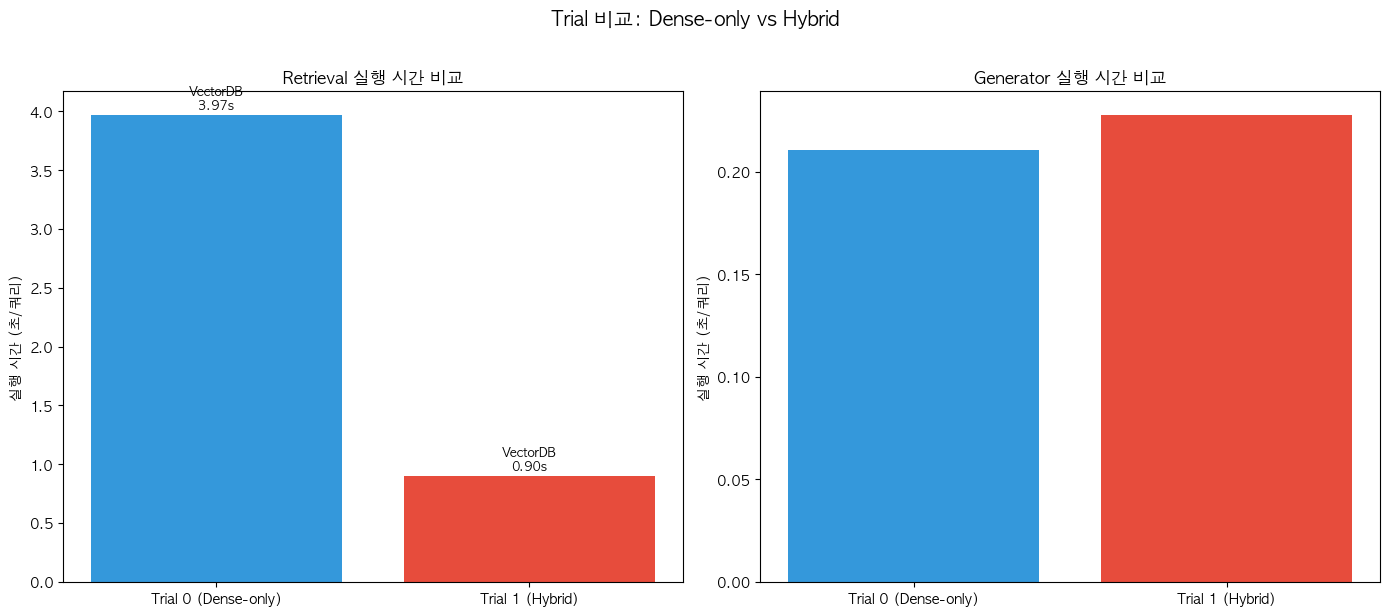

In [46]:
# Trial간 Retrieval 성능 비교 시각화
if len(trials) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    trial_names = list(trials.keys())

    # Retrieval 노드 비교
    retrieval_data = []
    for name, df in trials.items():
        retrieval_row = df[df['node_type'].str.contains('retrieval', case=False)].iloc[0] if len(df[df['node_type'].str.contains('retrieval', case=False)]) > 0 else None
        if retrieval_row is not None:
            retrieval_data.append({
                'trial': name,
                'module': retrieval_row['best_module_name'],
                'params': retrieval_row['best_module_params'],
                'time': retrieval_row['best_execution_time']
            })

    if retrieval_data:
        ret_df = pd.DataFrame(retrieval_data)
        colors = ['#3498db', '#e74c3c']
        bars = axes[0].bar(ret_df['trial'], ret_df['time'], color=colors[:len(ret_df)])
        axes[0].set_title('Retrieval 실행 시간 비교', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('실행 시간 (초/쿼리)')
        for bar, row in zip(bars, retrieval_data):
            axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                        f"{row['module']}\n{row['time']:.2f}s", ha='center', fontsize=9)

    # Generator 비교
    gen_data = []
    for name, df in trials.items():
        gen_row = df[df['node_type'] == 'generator'].iloc[0] if len(df[df['node_type'] == 'generator']) > 0 else None
        if gen_row is not None:
            gen_data.append({
                'trial': name,
                'module': gen_row['best_module_name'],
                'time': gen_row['best_execution_time']
            })

    if gen_data:
        gen_df = pd.DataFrame(gen_data)
        bars = axes[1].bar(gen_df['trial'], gen_df['time'], color=colors[:len(gen_df)])
        axes[1].set_title('Generator 실행 시간 비교', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('실행 시간 (초/쿼리)')

    plt.suptitle('Trial 비교: Dense-only vs Hybrid', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('비교를 위해 Trial 1 완료가 필요합니다.')

### 결과 해석: Trial 0 vs Trial 1

#### 최적 파이프라인 비교

| 구분 | Trial 0 (Dense-only) | Trial 1 (Hybrid) |
|------|---------------------|-------------------|
| **검색** | E5 VectorDB 단독 | E5 + BM25(ko_kiwi) → HybridCC → KoReranker |
| **프롬프트** | 영문 프롬프트 | 한국어 프롬프트 |
| **생성** | GPT-4o-mini (temp=0) | GPT-4o-mini (temp=0) |
| **검색 top_k** | 10개 | 5개 (Reranker가 필터링) |

#### 성능 비교

| 메트릭 | Trial 0 | Trial 1 | 승자 | 해석 |
|--------|---------|---------|------|------|
| Retrieval Recall | 0.95 | 0.94 | 무승부 | Reranker가 top_k를 줄여도 Recall 유지 |
| Retrieval F1 | 0.173 | **0.313** | **Trial 1** | Reranker가 Precision을 크게 개선 |
| Retrieval Precision | 0.095 | **0.188** | **Trial 1** | 5개 중 ~1개가 정답 (10개 중 ~1개보다 나음) |
| 검색 총 시간 | 3.97s | **11.35s** | Trial 0 | Hybrid는 KoReranker(8.87s)가 병목 |

> **핵심 트레이드오프**: Trial 1(Hybrid)은 **검색 정밀도가 2배** 좋지만, **처리 시간이 3배** 더 걸림  
> KoReranker(8.87초)가 전체 시간의 78%를 차지 → GPU 가속 시 대폭 개선 가능

---
## 5단계: 종합 결론

### 데이터셋 정보
벤치마크에 사용된 데이터의 규모와 출처를 확인합니다.

In [47]:
# 최종 결론 요약 테이블
print('=' * 70)
print('AutoRAG 벤치마크 최종 결과 요약')
print('=' * 70)

for trial_id in sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.isdigit()]):
    trial_dir = RESULTS_DIR / trial_id
    summary_path = trial_dir / 'summary.csv'
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        trial_label = 'Dense-only' if trial_id == '0' else 'Hybrid' if trial_id == '1' else f'Trial {trial_id}'
        print(f'\n--- Trial {trial_id} ({trial_label}) ---')
        for _, row in df.iterrows():
            print(f"  {row['node_type']:25s} → {row['best_module_name']} ({row['best_execution_time']:.4f}s)")
            print(f"  {'':25s}   params: {row['best_module_params']}")

print('\n' + '=' * 70)

AutoRAG 벤치마크 최종 결과 요약

--- Trial 0 (Dense-only) ---
  semantic_retrieval        → VectorDB (3.9716s)
                              params: {'top_k': 10, 'vectordb': 'e5_qdrant'}
  prompt_maker              → Fstring (0.0001s)
                              params: {'prompt': 'Based on the following context, answer the question.\n\nContext:\n{retrieved_contents}\n\nQuestion: {query}\n\nAnswer:'}
  generator                 → LlamaIndexLLM (0.2103s)
                              params: {'llm': 'openai', 'model': 'gpt-4o-mini', 'temperature': 0}

--- Trial 1 (Hybrid) ---
  semantic_retrieval        → VectorDB (0.9029s)
                              params: {'top_k': 10, 'vectordb': 'e5_qdrant'}
  lexical_retrieval         → BM25 (1.4969s)
                              params: {'top_k': 10, 'bm25_tokenizer': 'ko_kiwi'}
  hybrid_retrieval          → HybridCC (0.0841s)
                              params: {'top_k': 10, 'normalize_method': 'tmm', 'weight_range': (0.0, 1.0), 'test_weight_size

---
### 최종 권장 파이프라인

벤치마크 결과를 종합하면, **운영 환경에 따라 2가지 파이프라인**을 권장합니다:

#### 옵션 A: 속도 우선 (Simple Dense)
```
질문 → E5 multilingual VectorDB (top_k=10) → GPT-4o-mini (temp=0) → 답변
```
- **장점**: 빠르고 단순, Recall 0.95
- **단점**: 불필요한 문서가 섞일 수 있음 (Precision 0.095)
- **적합**: 실시간 챗봇, 빠른 응답이 중요한 서비스

#### 옵션 B: 정밀도 우선 (Full Hybrid)
```
질문 → E5 VectorDB + BM25(ko_kiwi) → HybridCC(tmm, w=0.48) → KoReranker (top_k=5) → GPT-4o-mini (temp=0) → 답변
```
- **장점**: F1 +81%, Precision +98% 개선, Recall 유지 (0.94)
- **단점**: KoReranker로 인해 처리 시간 증가 (GPU 가속 시 해결 가능)
- **적합**: 보고서 생성, 정확한 근거 제시가 필요한 업무

### 주요 발견 사항

1. **임베딩 모델**: E5 multilingual과 BGE-M3가 한국어 문서 검색에서 동률 1위. 비용 무료(로컬)이므로 실운영에 유리
2. **한국어 토크나이저**: Kiwi > OKT. 보고서/논문 같은 정형 문서에서 Kiwi가 더 정확한 형태소 분석
3. **Hybrid 융합**: Dense가 이미 강력(0.95)하여 BM25 추가 효과는 제한적. 하지만 키워드 정확 매칭이 필요한 경우 보완 가능
4. **Reranker가 핵심**: KoReranker가 F1을 81% 개선하는 가장 큰 성능 향상 요인. 한국어 Cross-encoder의 위력
5. **영어 모델 한계**: MiniLM(영어 전용), FlashRank(영어 Reranker) 모두 한국어에서 성능 급락 → **한국어 RAG에는 다국어/한국어 모델 필수**
6. **Temperature**: RAG에서는 0이 최적. 문서 기반 답변에서 창의성은 불필요

### 한계 및 향후 개선

- QA 데이터셋(100개)이 GPT-4o-mini로 생성되어, 같은 모델 평가 시 편향 가능성
- GPU 미사용 환경에서 테스트하여 HuggingFace 모델 속도가 실제보다 느리게 측정됨
- Upstage Solar 임베딩 등 추가 모델 테스트 필요
- 청킹 크기(500 vs 1024) 변수는 이번 벤치마크에서 미포함 → 후속 실험 대상